# CWS Model Test Notebook

Loads the fixed CWS pilot model, summarizes graph content, runs JSON Schema
and semantic validation via `KGModelValidator`, and displays the findings.

**Paths** are resolved relative to this notebook's directory, so the notebook
can be run from any working directory.

## 1. Setup paths

In [1]:
from pathlib import Path
import json
import importlib.util
import sys
import pandas as pd

# Resolve notebook directory regardless of Jupyter launch location
try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path().resolve()  # fallback: cwd (run notebook from test_mbse/)

VALIDATOR_DIR = (NOTEBOOK_DIR / '../../../knowledge_graph/validator').resolve()
SCHEMA_DIR    = (NOTEBOOK_DIR / '../../../knowledge_graph/schemas').resolve()

MODEL_PATH     = NOTEBOOK_DIR / 'model' / 'cws_pilot_model.json'
VALIDATOR_PATH = VALIDATOR_DIR / 'kg_model_validator.py'
TOML_SCHEMAS   = [
    SCHEMA_DIR / 'mbseSchema.toml',
]
REPORT_OUT = NOTEBOOK_DIR / 'model' / 'validation_report.json'

for p, label in [(MODEL_PATH, 'model'), (VALIDATOR_PATH, 'validator')] + [(p, p.name) for p in TOML_SCHEMAS]:
    status = 'OK' if p.exists() else 'MISSING'
    print(f'[{status}] {label}: {p}')

[OK] model: /Users/mandd/projects/DACKAR/src/dackar/RCA/tests/test_mbse/model/cws_pilot_model.json
[OK] validator: /Users/mandd/projects/DACKAR/src/dackar/knowledge_graph/validator/kg_model_validator.py
[OK] mbseSchema.toml: /Users/mandd/projects/DACKAR/src/dackar/knowledge_graph/schemas/mbseSchema.toml


## 2. Load model and schema

In [2]:
with MODEL_PATH.open('r', encoding='utf-8') as f:
    model = json.load(f)

model['metadata']

{'title': 'Circulating Water System Pilot Model',
 'schema_version': '3.1',
 'model_version': '1.0',
 'system': 'Circulating Water System',
 'scope': 'Three-pump, three-screen, three-condenser pilot with intake/discharge valves, trash removal, motor breakers, power feeds, and usage-level connectors',
 'generated_on': '2026-04-12'}

## 3. Graph content summary

In [3]:
summary = {f'nodes.{k}': len(v) for k, v in model.get('nodes', {}).items()}
summary.update({f'relations.{k}': len(v) for k, v in model.get('relations', {}).items()})
(
    pd.DataFrame(summary.items(), columns=['collection', 'count'])
    .sort_values('collection')
    .reset_index(drop=True)
)

,collection,count
0,nodes.connector,54
1,nodes.element_definition,13
2,nodes.element_usage,32
3,nodes.flow_definition,2
4,nodes.function_definition,4
5,nodes.port,72
6,nodes.port_type,5
7,nodes.requirement,5
8,nodes.technical_specification,5
9,relations.allocated_to,6


## 4. Load validator and run validation

In [4]:
# Dynamically load kg_model_validator from the knowledge_graph/validator package
_spec = importlib.util.spec_from_file_location('kg_model_validator', VALIDATOR_PATH)
_mod  = importlib.util.module_from_spec(_spec)
sys.modules[_spec.name] = _mod
_spec.loader.exec_module(_mod)

validator = _mod.KGModelValidator(model, toml_schema_paths=TOML_SCHEMAS)
report    = validator.validate()

report['summary']

{'total_findings': 0, 'errors': 0, 'warnings': 0, 'info': 0}

## 5. Findings table

In [5]:
findings = pd.DataFrame(report['findings'])
findings

""


## 6. Findings breakdown by severity and rule

In [6]:
if findings.empty:
    print('No findings — model is clean.')
else:
    (
        findings.groupby(['severity', 'rule_id'])
        .size()
        .reset_index(name='count')
        .sort_values(['severity', 'count'], ascending=[True, False])
    )

No findings — model is clean.


## 7. Connector-port detail (C1/C5 diagnostic)

In [7]:
cp = pd.DataFrame(model['relations'].get('connects_port', []))
cn = pd.DataFrame(model['nodes'].get('connector', []))[['id', 'name', 'directionality']]

if cp.empty or cn.empty:
    print('No connector/port data found.')
else:
    (
        cp.merge(cn, left_on='from', right_on='id', how='left')
        [['from', 'name', 'to', 'endpoint_role', 'direction_hint', 'sequence_index']]
        .sort_values(['from', 'sequence_index'])
    )

## 8. Save report to disk

In [8]:
REPORT_OUT.write_text(json.dumps(report, indent=2), encoding='utf-8')
print(f'Report written to: {REPORT_OUT}')

Report written to: /Users/mandd/projects/DACKAR/src/dackar/RCA/tests/test_mbse/model/validation_report.json


## 9. Visualize CWS

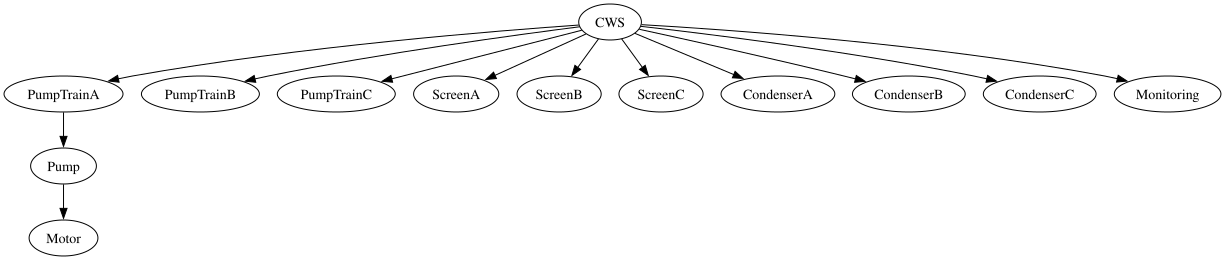

In [9]:
from graphviz import Digraph

# BDD
bdd = Digraph()
bdd.attr(rankdir='TB')

bdd.node('CWS')

for s in ['PumpTrainA','PumpTrainB','PumpTrainC',
          'ScreenA','ScreenB','ScreenC',
          'CondenserA','CondenserB','CondenserC',
          'Monitoring']:
    bdd.node(s)
    bdd.edge('CWS', s)

bdd.node('Pump')
bdd.node('Motor')
bdd.edge('PumpTrainA','Pump')
bdd.edge('Pump','Motor')

bdd

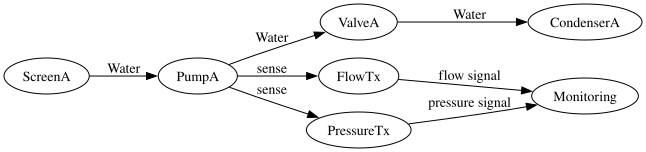

In [10]:
# IBD
ibd = Digraph()
ibd.attr(rankdir='LR')

ibd.node('ScreenA')
ibd.node('PumpA')
ibd.node('ValveA')
ibd.node('CondenserA')
ibd.node('Monitoring')

ibd.edge('ScreenA','PumpA', label='Water')
ibd.edge('PumpA','ValveA', label='Water')
ibd.edge('ValveA','CondenserA', label='Water')

ibd.node('FlowTx')
ibd.node('PressureTx')

ibd.edge('PumpA','FlowTx', label='sense')
ibd.edge('PumpA','PressureTx', label='sense')
ibd.edge('FlowTx','Monitoring', label='flow signal')
ibd.edge('PressureTx','Monitoring', label='pressure signal')

ibd